# Description

This notebook will look at the additional tests that participants completed. All tests can be grouped in the following categories:

* Personality and Habituation Behaviors
* Mind-wandering / Mindfulness
* Synesthesia
* Cognitive Control / Sustained Attention
* Creativity

In [1]:
import bokeh
print(bokeh.__version__)

3.7.3


In [2]:
import pandas as pd
import numpy as np
import xarray as xr
import seaborn as sns
import matplotlib.pyplot as plt
import hvplot.pandas
import panel as pn
import holoviews as hv
import os.path as osp
from scipy.stats import pearsonr, spearmanr, ttest_ind, mannwhitneyu
from tqdm import tqdm
from utils.basics import ORIG_BEHAV_DIR, SNYCQ_CLUSTERS_INFO_PATH,RESOURCES_SNYCQ_DIR
from utils.basics import get_sbj_scan_list

mkdir -p failed for path /path/to/your/new/cache/matplotlib: [Errno 13] Permission denied: '/path'
Matplotlib created a temporary cache directory at /tmp/matplotlib-q4t0yvxa because there was an issue with the default path (/path/to/your/new/cache/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


We will use this function to compute Cohen's d across scan sets

In [3]:
def cohens_d(x0, x1):
    m0, m1 = np.nanmean(x0), np.nanmean(x1)
    s0, s1 = np.nanstd(x0, ddof=1), np.nanstd(x1, ddof=1)
    n0, n1 = np.sum(~np.isnan(x0)), np.sum(~np.isnan(x1))
    sp = np.sqrt(((n0-1)*s0**2 + (n1-1)*s1**2) / (n0 + n1 - 2))
    return (m1 - m0) / sp if sp > 0 else np.nan

We will use this function to show heatmaps with srtatistical significance marked via BOLD black outlines

In [4]:
def show_results(data_val,data_pval=None,pval_thr=0.05, clabel=None,height=600,width=700,cmap='RdBu_r', fontscale=1, clim=(-.7,.7)):

    # Get the bokeh plot hooks
    def highlight_cell_hook(plot, element):
        # This hook will be called during the plot creation process
        fig = plot.state  # The figure object
        
        # Coordinates of the cell to highlight (e.g., cell at x=5, y=3)
        for r,row in data_pval_indexed_long.iterrows():
            if row['pval']:
                highlight_x = row['col'] + 0.5
                highlight_y = row['index'] + 0.5
                fig.rect(x=highlight_x,y=highlight_y,width=1,height=1,line_color='black',line_width=2,fill_alpha=0,name='highlight')
                
    # Create basic heatmap
    data_val_long    = data_val.melt(ignore_index=False,var_name=data_val.columns.name,value_name=data_val.name).reset_index()
    data_val_long    = data_val_long[[data_val.columns.name,data_val.index.name,data_val.name]]
    data_val_heatmap = hv.HeatMap(data_val_long).opts(tools=['hover'], 
                                                      height=height, width=width,
                                                      fontscale=fontscale,cmap=cmap,clim=clim, line_color='k',line_width=.1).opts(xrotation=90, colorbar=True, clabel=clabel)
    # If not enough information to highlight statistical significance is provided then return basic heatmap
    if (data_pval is None) or (pval_thr is None):
        return data_pval_heatmap
    # Prepare pval df so that it has indexes and cols as integers --> these are the plotting coordinates
    data_pval_indexed      = (data_pval < pval_thr).reset_index(drop=True).T.reset_index(drop=True).T
    data_pval_indexed.columns.name = data_pval.columns.name
    data_pval_indexed.index.name   = data_pval.index.name
    data_pval_indexed.name         = data_pval.name
    data_pval_indexed_long = data_pval_indexed.melt(ignore_index=False,var_name=data_pval.columns.name,value_name=data_pval.name).reset_index()
    data_pval_indexed_long = data_pval_indexed_long[[data_pval.columns.name,data_pval.index.name,data_pval.name]]
    data_pval_indexed_long.columns = ['col','index','pval']

    data_val_heatmap_highlighted = data_val_heatmap.opts(hooks=[highlight_cell_hook])
    
    return data_val_heatmap_highlighted
    

We will use this function to plot distribution of items across both scan Sets

In [5]:
def plot_distributions_across_NBS_groups(phenotype,df,groups_info, show_hist=True):
    # Extract gouping info:
    group_labels = list(groups_info.keys())
    group1       = groups_info[group_labels[0]]
    group2       = groups_info[group_labels[1]]
    # Check for missing subjects
    N_missing = 0
    for sbj in group1+group2:
        if sbj not in df.dropna().index:
            print(sbj,end=',')
            N_missing += 1
    print('\n++ Number of missing subjects for [%s] = %d' % (phenotype,N_missing))
    # Create dataframe for plotting
    df_NBS = df.copy()
    df_NBS = df_NBS.loc[group1+group2]
    df_NBS['Group'] = 'N/A'
    df_NBS.loc[group1,'Group'] = group_labels[0]
    df_NBS.loc[group2,'Group'] = group_labels[1]
    df_NBS = df_NBS.dropna()
    print(df_NBS['Group'].value_counts())
    print('============================')
    # Create plot
    if show_hist:
        fig = (df_NBS.hvplot.hist(by='Group',normed=True, alpha=0.5, bins=25) * df_NBS.hvplot.kde(by='Group')).opts(legend_position='top_right', title=phenotype)
    else:
        fig = df_NBS.hvplot.kde(by='Group').opts(legend_position='top_right', title=phenotype)
    # Perform statistics
    df_NBS = df_NBS.reset_index(drop=True).set_index('Group')
    print(ttest_ind(df_NBS.loc[group_labels[0]].values,df_NBS.loc[group_labels[1]].values))
    print(mannwhitneyu(df_NBS.loc[group_labels[0]].values,df_NBS.loc[group_labels[1]].values))
    return fig

***

# 1. Create data structures with basic information about behavioral measures available as part of the Mind-Brain-Body Dataset

1. Here is a list of all available surveys organized by category

This list was created taking into accoun that a few test are not available at the [download page](https://dataverse.harvard.edu/dataset.xhtml?persistentId=doi:10.7910/DVN/VMJ6NV). Those are:

* FBI (Facebook intensity scale)
* MGIQ (Multi-gender identity questionnaire)

Also, for two CogControl task, there is the need for computing summary metrics, so we will ignored them by now

* I found code for CCPT
* Not sure what to do with ETS

In [6]:
surveys_per_category = {
    'Personality':          ['AMAS','ASR','BDI','BISBAS','BCQ','BPS','SCS','ESS','GoldMSI','HADS','IAT','IMIS','MPU','MMI','NEO','PSSI','SE','SD3','SDS','TPS','UPPS'],
    'Mind-wandering':       ['FFMQ','MCQ','SDMW','VISQ'],
    'Synesthesia':          ['SYN'],
    'CogControl-Attention': ['ACS'],
    'Creativity':           ['AUT','CAQ','RAT','TCIA']
}
all_surveys =  [ x for xs in surveys_per_category.values() for x in xs ]

for survey in surveys_per_category:
    print('%s has %d surveys' % (survey, len(surveys_per_category[survey])))

Personality has 21 surveys
Mind-wandering has 4 surveys
Synesthesia has 1 surveys
CogControl-Attention has 1 surveys
Creativity has 4 surveys


The next dicitionary contains information about the different summary metrics available per survey

In [7]:
metrics_per_survey = {'AMAS':['AMAS_sum'],
                      'ASR':['ASR_summary_adaptiveFunctioning_friends_sum','ASR_summary_adaptiveFunctioning_spouse_sum','ASR_summary_adaptiveFunctioning_family_sum','ASR_summary_adaptiveFunctioning_job_sum','ASR_summary_adaptiveFunctioning_education_sum',
                           'ASR_scale_substanceUse_tabaco_perday', 'ASR_scale_substanceUse_alcohol_daysdrunk','ASR_scale_substanceUse_drugs_daysused','ASR_summary_criticalItems_sum', 
                           'ASR_summary_syndromeProfiles_anxiousdepressed_sum', 'ASR_summary_syndromeProfiles_withdrawn_sum','ASR_summary_syndromeProfiles_somaticComplaints_sum','ASR_summary_syndromeProfiles_thoughtProblems_sum',
                           'ASR_summary_syndromeProfiles_attentionProblems_sum','ASR_summary_syndromeProfiles_aggressiveBehavior_sum','ASR_summary_syndromeProfiles_rulebreakingBehavior_sum','ASR_summary_syndromeProfiles_intrusive_sum',
                           'ASR_summary_syndromeProfiles_internalizing_sum','ASR_summary_syndromeProfiles_externalizing_sum'],
                      'BDI':['BDI_summary_sum'],
                      'BISBAS':['BISBAS_BIS_sum','BISBAS_BAS_sum'],
                      'BCQ':['BCQ_private_body_mean', 'BCQ_public_body_mean','BCQ_body_competence_mean'],
                      'BPS':['BPS_sum'],
                      'SCS':['SCS_SelfCtrl_sum'],
                      'ESS':['ESS_summary_sum'],
                      'GoldMSI': ['GoldMSI_Active_sum', 'GoldMSI_Training_sum'],
                      'HADS':['HADS-A_summary_sum', 'HADS-D_summary_sum'],
                      'IAT':['IAT_sum'],
                      'IMIS':['IMIS_NegVal_sum', 'IMIS_Help_sum', 'IMIS_Movement_sum','IMIS_PersRef_sum'],
                      'MPU':['MPU_1','MPU_2','MPU_3','MPU_4','MPU_5','MPU_6','MPU_7','MPU_8','MPU_9','MPU_10','MPU_11','MPU_12','MPU_13','MPU_14','MPU_15','MPU_16','MPU_17','MPU_18','MPU_19'],
                      'MMI':['MMI_score'], 
                      'NEO':['NEO_N','NEO_E','NEO_O','NEO_A','NEO_C'],
                      'PSSI':['PSSI_PN', 'PSSI_SZ', 'PSSI_ST', 'PSSI_BL', 'PSSI_HI', 'PSSI_NA','PSSI_SU', 'PSSI_AB', 'PSSI_ZW', 'PSSI_NT', 'PSSI_DP', 'PSSI_SL','PSSI_RH', 'PSSI_AS'],
                      'SE':['SE_Mean_SelfEst'],
                      'SDS':['SDS_sum'],
                      'TPS':['TPS_D_sum'],
                      'UPPS':['UPPS_Mean_NegUrg', 'UPPS_Mean_Premed', 'UPPS_Mean_Persev','UPPS_Mean_SS', 'UPPS_Mean_PosUrg'],
                      'FFMQ':['FFMQ_observe_sum', 'FFMQ_describe_sum', 'FFMQ_act_awareness_sum','FFMQ_nonjudge_sum', 'FFMQ_nonreact_sum'],
                      'MCQ':['MCQ_lack_of_cogn_conf_mean', 'MCQ_pos_bel_about_worry_mean','MCQ_cogn_self-consc_mean', 'MCQ_neg_bel_about_uncontr_danger_mean','MCQ_need_contr_thoughts_mean'],
                      'SDMW':['S-D-MW_delib_mean', 'S-D-MW_spont_mean'],
                      'VISQ':['VIS_dialog_sum', 'VIS_condensed_sum', 'VIS_other_sum', 'VIS_eval_sum'],
                      'ACS':['ACS_sum'],
                      'AUT':['AUT_Fluency', 'AUT_creative_quality', 'AUT_Elaboration_mean', 'AUT_Average_Uniqueness'],
                      'CAQ':['CAQ_score'],
                      'RAT':['RAT_CORRECT_NR', 'RAT_PERCENT', 'RAT_Rtmeanforcorrectanswers'],
                      'TCIA':['TCIA_Vividness_mean', 'TCIA_Orig_mean', 'TCIA_Transform_mean']}

2. Gather the path to the files associated with each survey

In [8]:
SURVEYS_DIR = osp.join(ORIG_BEHAV_DIR,'behavioral_data_MPILMBB','phenotype')

In [9]:
# Create strucutres with access to the files associated with them
survey_data_paths = {}
survey_info_paths = {}
for test in tqdm(all_surveys, desc='Test'):
    data_file = osp.join(SURVEYS_DIR,f"{test}.tsv")
    info_file = osp.join(SURVEYS_DIR,f"{test}.json")
    if (not osp.exists(data_file)) or (not osp.exists(info_file)):
        print(f"++ WARNING: Cannot find both files for test {test}")
    else:
        survey_data_paths[test] = data_file
        survey_info_paths[test] = info_file

Test: 100%|██████████| 31/31 [00:00<00:00, 1791.45it/s]


***
# 2. Analysis regarding the role of dispositional traits in population differences (NBS results)

1. Load the list of all scans in the NBS groups

In [10]:
emb_plus     = pd.read_csv(osp.join(RESOURCES_SNYCQ_DIR, 'SNYCQ_tsne_embeddings_plus.csv'), index_col=[0,1])
clusters_info = emb_plus[['Set Label','Group Probability']]

2. Get the subjects in each group

In [11]:
# All subjects entering NBS analyses
sbjs_in_SetA    = list(clusters_info[clusters_info['Set Label']=='Set A'].index.get_level_values('Subject').unique())
sbjs_in_SetB    = list(clusters_info[clusters_info['Set Label']=='Set B'].index.get_level_values('Subject').unique())
sbjs_in_Both    = list(set(sbjs_in_SetA).intersection(set(sbjs_in_SetB)))
NBS_all_sbjs    = sbjs_in_SetA + sbjs_in_SetB

print('++ Scans in NBS groups (this will include scans and subjects that are in both groups)')
print('++ Number of scans/subjects in group [Set A]: %d/%d' % (clusters_info[clusters_info['Set Label']=='Set A'].shape[0],len(sbjs_in_SetA)))
print('++ Number of scans/subjects in group [Set B]: %d/%d' % (clusters_info[clusters_info['Set Label']=='Set B'].shape[0],len(sbjs_in_SetB)))
print('++ Number of scans/subjects in both groups:   %d/%d' % (clusters_info[clusters_info['Set Label']!='Ambiguous'].shape[0],len(sbjs_in_Both)))

++ Scans in NBS groups (this will include scans and subjects that are in both groups)
++ Number of scans/subjects in group [Set A]: 127/64
++ Number of scans/subjects in group [Set B]: 250/106
++ Number of scans/subjects in both groups:   377/43


3. Keep only subjects that are in one of the two sets only

In [12]:
sbjs_in_SetB    = [item for item in sbjs_in_SetB if item not in sbjs_in_Both]
sbjs_in_SetA    = [item for item in sbjs_in_SetA if item not in sbjs_in_Both]
NBS_all_sbjs    = sbjs_in_SetA + sbjs_in_SetB

print('++ Number of scans/subjects in group [Set A]: %d' % len(sbjs_in_SetA))
print('++ Number of scans/subjects in group [Set B]: %d' % len(sbjs_in_SetB))

++ Number of scans/subjects in group [Set A]: 21
++ Number of scans/subjects in group [Set B]: 63


4. For a few surveys, subjects name do not agree at all (most likely associagted with the other portion of the dataset that we do not analyze here). We identify such surveys by seeing there is zero overlap in subject labels between the subjects entering NBS and the subjects in the survey index. Such surveys are eliminated

In [13]:
# Look for surveys that do not include information about the subjects we are using
surveys_to_remove_insuficient_subjects = []
for survey in tqdm(all_surveys):
    df      = pd.read_csv(survey_data_paths[survey], sep='\t', index_col=0)
    df_sbjs = list(df.index.values)
    intersection_w_NBS = set(df_sbjs).intersection(NBS_all_sbjs)
    if (len(intersection_w_NBS) == 0) :
        surveys_to_remove_insuficient_subjects.append(survey)
print('++ Surveys that contain information about another subject group: %s' % surveys_to_remove_insuficient_subjects)

100%|██████████| 31/31 [00:00<00:00, 598.65it/s]

++ Surveys that contain information about another subject group: ['SD3', 'SYN']


In [14]:
# Remove those surveys from the list of available surveys
aux = {}
for category,surveys in surveys_per_category.items():
    new_list = [i for i in surveys if i not in surveys_to_remove_insuficient_subjects]
    if len(new_list) > 0:
        aux[category] = new_list
NBS_surveys = [ x for xs in aux.values() for x in xs ]
print('++ New set of surveys:')
NBS_surveys_per_category = aux
for category,surveys in NBS_surveys_per_category.items():
    print(' + %s has %d surveys in it: %s' % (category, len(surveys), str(surveys)))

++ New set of surveys:
 + Personality has 20 surveys in it: ['AMAS', 'ASR', 'BDI', 'BISBAS', 'BCQ', 'BPS', 'SCS', 'ESS', 'GoldMSI', 'HADS', 'IAT', 'IMIS', 'MPU', 'MMI', 'NEO', 'PSSI', 'SE', 'SDS', 'TPS', 'UPPS']
 + Mind-wandering has 4 surveys in it: ['FFMQ', 'MCQ', 'SDMW', 'VISQ']
 + CogControl-Attention has 1 surveys in it: ['ACS']
 + Creativity has 4 surveys in it: ['AUT', 'CAQ', 'RAT', 'TCIA']


5. For the surveys still remaining, we will now remove all surveys that do not provide information in at least 70% of subjects in the NBS analyses

In [15]:
NBS_sbjs_avail_per_survey                   = {'N_avail':pd.DataFrame(columns=['NBS_SetA','NBS_SetB'])}
surveys_to_remove_insuficient_subjects_NBS  = []
percentage_needed_subjects = 0.7
for category, surveys in NBS_surveys_per_category.items():
    for survey in surveys:
        df         = pd.read_csv(survey_data_paths[survey], sep='\t', index_col=0)
        df         = df.loc[:, metrics_per_survey[survey]]
        avail_sbjs = list(df.dropna().index)
        num_avail_NBS_A = len(set(avail_sbjs).intersection(set(sbjs_in_SetA)))
        num_avail_NBS_B = len(set(avail_sbjs).intersection(set(sbjs_in_SetB)))
        NBS_sbjs_avail_per_survey['N_avail'].loc[survey,'NBS_SetA'] = num_avail_NBS_A
        NBS_sbjs_avail_per_survey['N_avail'].loc[survey,'NBS_SetB'] = num_avail_NBS_B
        if (num_avail_NBS_A < (len(sbjs_in_SetA) * percentage_needed_subjects)) or (num_avail_NBS_B < (len(sbjs_in_SetB) * percentage_needed_subjects)):
                surveys_to_remove_insuficient_subjects_NBS.append(survey)
surveys_to_remove_insuficient_subjects_NBS

['ASR', 'BCQ', 'MPU', 'NEO', 'FFMQ', 'MCQ', 'AUT', 'CAQ', 'RAT', 'TCIA']

In [16]:
# Remove those surveys from the list of available surveys
aux = {}
for category,surveys in NBS_surveys_per_category.items():
    new_list = [i for i in surveys if i not in surveys_to_remove_insuficient_subjects_NBS]
    if len(new_list) > 0:
        aux[category] = new_list
NBS_surveys = [ x for xs in aux.values() for x in xs ]
NBS_surveys_per_category = aux
print('++ New set of surveys:')
for category,surveys in NBS_surveys_per_category.items():
    print(' + %s has %d surveys in it: %s' % (category, len(surveys), str(surveys)))

++ New set of surveys:
 + Personality has 16 surveys in it: ['AMAS', 'BDI', 'BISBAS', 'BPS', 'SCS', 'ESS', 'GoldMSI', 'HADS', 'IAT', 'IMIS', 'MMI', 'PSSI', 'SE', 'SDS', 'TPS', 'UPPS']
 + Mind-wandering has 2 surveys in it: ['SDMW', 'VISQ']
 + CogControl-Attention has 1 surveys in it: ['ACS']


6. Compute T-test and Mann-Whitney for all selected surveys

In [17]:
NBS_ttest = pd.DataFrame(columns=['T','pval'])
NBS_mw    = pd.DataFrame(columns=['U','pval'])
NBS_cohen_d = pd.DataFrame(columns=['d'])

In [18]:
for category,surveys in NBS_surveys_per_category.items():
    for survey in surveys:
        df_survey   = pd.read_csv(survey_data_paths[survey], sep='\t', index_col=0)
        for metric in tqdm(metrics_per_survey[survey],desc=survey):
            df                            = pd.DataFrame(df_survey[metric]) # In case there is more than one metric
            df['Group']                   = 'N/A'
            df.loc[sbjs_in_SetA,'Group']  = 'SetA'
            df.loc[sbjs_in_SetB,'Group']  = 'SetB'
            df                            = df.dropna()
            df                            = df.reset_index(drop=True).set_index('Group')
            set_a_values = df.loc['SetA'].values.squeeze()
            set_b_values = df.loc['SetB'].values.squeeze()
            NBS_ttest.loc[metric,'T'],NBS_ttest.loc[metric,'pval'] =    ttest_ind(set_a_values, set_b_values, alternative='two-sided')
            NBS_mw.loc[metric,'U'],   NBS_mw.loc[metric,'pval']    = mannwhitneyu(set_a_values, set_b_values, alternative='two-sided')
            NBS_cohen_d.loc[metric,'d'] = cohens_d(set_b_values,set_a_values)
NBS_ttest = NBS_ttest.infer_objects()
NBS_mw    = NBS_mw.infer_objects()

BDI: 100%|██████████| 1/1 [00:00<00:00, 162.87it/s]


ACS: 100%|██████████| 1/1 [00:00<00:00, 196.75it/s]


In [19]:
pBonf_NBS = 0.05 / NBS_ttest.shape[0]
NBS_ttest['T (pBonf<0.05)'] = NBS_ttest['T']
NBS_ttest['T (p<0.05)'] = NBS_ttest['T']
NBS_ttest.loc[NBS_ttest['pval'] > pBonf_NBS, 'T (pBonf<0.05)'] = np.nan
NBS_ttest.loc[NBS_ttest['pval'] > 0.05, 'T (p<0.05)'] = np.nan

NBS_mw['U (pBonf<0.05)'] = NBS_mw['U']
NBS_mw['U (p<0.05)'] = NBS_mw['U']
NBS_mw.loc[NBS_mw['pval'] > pBonf_NBS, 'U (pBonf<0.05)'] = np.nan
NBS_mw.loc[NBS_mw['pval'] > 0.05, 'U (p<0.05)'] = np.nan

In [20]:
plot = NBS_cohen_d.hvplot.heatmap(height=600, fontscale=1,line_color='k',line_width=1, width=245, clim=(-2,2), cmap='RdBu_r').opts(xrotation=90, 
                                                                                                              clabel='Cohen`s d (Set A - Set B)', 
                                                                                                              shared_axes=False) + \
NBS_ttest.drop('pval',axis=1).hvplot.heatmap(height=600, fontscale=1,cmap='RdBu_r',clim=(-3,3), line_color='k',line_width=1, width=275).opts(xrotation=90, clabel='Paired T-stat', shared_axes=False) + \
NBS_mw.drop('pval',axis=1).hvplot.heatmap(height=600, fontscale=1,cmap='RdBu_r',line_color='k',line_width=1, width=275).opts(xrotation=90, clabel='Mann-Whitney U statistic')

### Saving figure in SVG format and also source data file

In [25]:
NBS_cohen_d.to_csv('./source_data_files/figure_04_a.csv')
NBS_ttest.to_csv('./source_data_files/figure_04_b.csv')
NBS_mw.to_csv('./source_data_files/figure_04_c.csv')

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
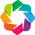

'/vf/users/SFIMJGC_Introspec/2023_fc_introspection/code/fc_introspection/notebooks/figures/Figure04.html'

In [21]:
import holoviews as hv

from bokeh.io import save
from bokeh.models.plots import Plot
from bokeh.resources import INLINE

hv.extension("bokeh")

bokeh_obj = hv.render(plot, backend="bokeh")

# Set SVG backend on every Bokeh plot inside the rendered object
if isinstance(bokeh_obj, Plot):
    bokeh_obj.output_backend = "svg"

for p in bokeh_obj.select({"type": Plot}):
    p.output_backend = "svg"

save(
    bokeh_obj,
    filename="./figures/Figure04.html",
    resources=INLINE,
    title="Figure04",
)

![Figure04](./figures/Figure04.png)

In [21]:
NBS_ttest.drop(['T (pBonf<0.05)'],axis=1).dropna()

,T,pval,T (p<0.05)
BDI_summary_sum,2.192740,0.031159,2.192740
BISBAS_BIS_sum,2.009527,0.047985,2.009527
GoldMSI_Active_sum,-2.330062,0.022261,-2.330062
HADS-A_summary_sum,2.275975,0.025455,2.275975
HADS-D_summary_sum,4.280915,0.000050,4.280915
PSSI_SU,2.037038,0.044872,2.037038
PSSI_AB,2.235842,0.028079,2.235842
SE_Mean_SelfEst,-2.494335,0.014628,-2.494335


In [22]:
NBS_mw.drop(['U (pBonf<0.05)'],axis=1).dropna()

,U,pval,U (p<0.05)
BDI_summary_sum,863.0,0.036939,863.0
GoldMSI_Active_sum,453.0,0.031488,453.0
HADS-D_summary_sum,985.5,0.000736,985.5
PSSI_SU,862.5,0.037786,862.5
SE_Mean_SelfEst,459.5,0.036330,459.5


***
# 2.  Role of dispositional traits in Predictive Analyses (CPMs)

1. Load the SNYCQ answers

In [26]:
_, _, snycq_df = get_sbj_scan_list(when='post_motion', return_snycq=True)
snycq_df.drop(['Vigilance'],axis=1,inplace=True)

++ [post_motion] Number of subjects: 133 subjects
++ [post_motion] Number of scans:    471 scans


2. Extract list of 469 scans entering the CPM analyses

In [27]:
# We do it this way so that we remove the two scans marked as outliers during the initial evaluation of the experiential data
scan_list = emb_plus.index


3. Load the ICQF Thought Pattern loadings

In [28]:
W = pd.read_csv('../resources/snycq/SNYCQ_W.csv', index_col=[0,1])
W.columns = ['TP1','TP2']
W = W.loc[scan_list]

4. Update the ```SNYCA_df``` dataframe with the thought patterns loadings just loaded

In [29]:
snycq_df = pd.concat([snycq_df, W], axis=1)

5. Behavioral data is only available once per subject, so that we need a single measure of experiential data per subject --> we use the mean   

In [30]:
snyq_by_subject_df = snycq_df.groupby('Subject').mean()
sbj_list = list(snyq_by_subject_df.index)

In [31]:
# All diemsnions available to be checked
introspection_dimensions = list(snyq_by_subject_df.columns)

In [32]:
# Final list of subjects entering the CPM analyses
CPM_all_sbjs = list(snyq_by_subject_df.index.values)
print(len(CPM_all_sbjs))

133


6. Compute correlations between in-scanner experience measures and dispositional trait measures

In [33]:
CPM_R  = pd.DataFrame(columns=snycq_df.columns); CPM_R.name  = 'R'
CPM_Rp = pd.DataFrame(columns=snycq_df.columns); CPM_Rp.name = 'R_pval'
CPM_S  = pd.DataFrame(columns=snycq_df.columns); CPM_S.name  = 'S'
CPM_Sp = pd.DataFrame(columns=snycq_df.columns); CPM_Sp.name = 'S_pval'

In [34]:
for category,surveys in NBS_surveys_per_category.items():
    for survey in surveys:
        df_survey      = pd.read_csv(survey_data_paths[survey], sep='\t', index_col=0)
        sbjs_in_survey = list(df_survey.dropna().index)
        sbjs_to_use    = list(set(sbj_list).intersection(set(sbjs_in_survey)))
        df_survey      = df_survey.loc[sbjs_to_use, metrics_per_survey[survey]]
        for metric in tqdm(metrics_per_survey[survey],desc=survey):
            df = pd.DataFrame(df_survey[metric]) # In case there is more than one metric
            df = df.dropna()
            for col in introspection_dimensions:
                CPM_R.loc[metric,col], CPM_Rp.loc[metric,col] = pearsonr(snyq_by_subject_df.loc[sbjs_to_use,col].values.squeeze(), df.loc[sbjs_to_use,metric].values.squeeze())
                CPM_S.loc[metric,col], CPM_Sp.loc[metric,col] = spearmanr(snyq_by_subject_df.loc[sbjs_to_use,col].values.squeeze(),df.loc[sbjs_to_use,metric].values.squeeze())
for aux in [CPM_R,CPM_Rp,CPM_S,CPM_Sp]:
    aux = aux.infer_objects()
    aux.index.name  = 'Other Traits'
    aux.columns.name = 'SNYCQ + Thought Patterns'
    
CPM_pBonf = 0.05 / CPM_R.shape[0]
print(CPM_pBonf)

AMAS:   0%|          | 0/1 [00:00<?, ?it/s]

ACS: 100%|██████████| 1/1 [00:00<00:00, 33.96it/s]

0.0010869565217391304


7. Plot the results based both in R and Spearman R

In [35]:
plot = show_results(CPM_R,CPM_Rp,CPM_pBonf,clabel='Pearson Correlation (R) | pBONF < 0.05') 
hv.save(plot, './figures/Figure09.html')
plot

:HeatMap   [SNYCQ + Thought Patterns,Other Traits]   (R)

![Figure09](./figures/Figure09.png)

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
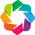

'/vf/users/SFIMJGC_Introspec/2023_fc_introspection/code/fc_introspection/notebooks/figures/Figure09.html'

In [36]:
hv.extension("bokeh")

bokeh_obj = hv.render(plot, backend="bokeh")

# Set SVG backend on every Bokeh plot inside the rendered object
if isinstance(bokeh_obj, Plot):
    bokeh_obj.output_backend = "svg"

for p in bokeh_obj.select({"type": Plot}):
    p.output_backend = "svg"

save(
    bokeh_obj,
    filename="./figures/Figure09.html",
    resources=INLINE,
    title="Figure09",
)

In [38]:
CPM_R.to_csv('./source_data_files/figure09_R.csv')

In [43]:
CPM_Rp.to_csv('./source_data_files/figure09_p.csv', float_format='%.5f')